# Notebook 01: Sequence Retrieval and Conservation Analysis

## Aim
Retrieve 16S ribosomal RNA sequences for all three formally recognised 
subspecies of *Xylella fastidiosa* from NCBI GenBank, perform a multiple 
sequence alignment using MAFFT, and identify conserved regions as candidate 
target sites for toehold switch design.

## Biological rationale
*Xylella fastidiosa* produces 16S ribosomal RNA constitutively and in high 
copy number, making it an ideal diagnostic target. The 16S rRNA gene contains 
both conserved regions shared across all bacteria and variable regions specific 
to particular taxa. We target the variable regions that are conserved across 
all three *X. fastidiosa* subspecies but absent or divergent in related 
non-target organisms including the plant host.

The three formally recognised subspecies are:
- *X. fastidiosa* subsp. *fastidiosa*
- *X. fastidiosa* subsp. *multiplex*  
- *X. fastidiosa* subsp. *pauca*

## Output
A FASTA file of aligned 16S rRNA sequences and a conservation plot 
identifying candidate target regions for notebook 02.

## 1. Setup and configuration

In [3]:
# Standard library imports
import os
import time
import subprocess

# Biopython imports for NCBI access and sequence handling
from Bio import Entrez, SeqIO

# Data handling and visualisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Set up paths relative to the notebook location
# This ensures the pipeline works regardless of where the repo is cloned
notebook_dir = os.path.dirname(os.path.abspath("01_sequence_retrieval.ipynb"))
project_root = os.path.dirname(notebook_dir)
data_dir = os.path.join(project_root, "data")
results_dir = os.path.join(project_root, "results")

print("Project root:", project_root)
print("Data directory:", data_dir)
print("Results directory:", results_dir)

Project root: /home/andre/xylella-toehold-biosensor
Data directory: /home/andre/xylella-toehold-biosensor/data
Results directory: /home/andre/xylella-toehold-biosensor/results


## 2. NCBI credentials

Your email address is stored in a local configuration file that is excluded 
from version control via .gitignore. This prevents personal information from 
being pushed to GitHub while still satisfying NCBI's requirement that all 
Entrez requests identify the user.

Create the file config.py in the project root with the following content:

ENTREZ_EMAIL = "your-email@example.com"

This file is listed in .gitignore and will never be pushed to GitHub.

In [4]:
# Import email from local config file that is excluded from GitHub
# If config.py does not exist, you will see an ImportError here
# Create it in the project root before running this cell
import sys
sys.path.insert(0, project_root)

try:
    from config import ENTREZ_EMAIL
    Entrez.email = ENTREZ_EMAIL
    print("Entrez email set successfully")
except ImportError:
    print("ERROR: config.py not found in project root")
    print("Create config.py with: ENTREZ_EMAIL = 'your-email@example.com'")

Entrez email set successfully


## 3. Sequence retrieval from NCBI

We use Entrez.esearch to query the NCBI nucleotide database for 16S ribosomal 
RNA sequences from each subspecies separately, then Entrez.efetch to retrieve 
the full records in GenBank format.

We use usehistory=y to store search results on the NCBI server and retrieve 
them in batches, which is more efficient and reliable than fetching one 
record at a time. A short delay is added between requests to respect NCBI 
usage limits of 3 requests per second without an API key.

In [5]:
def fetch_16S_sequences(subspecies_name, max_sequences=15):
    """
    Search NCBI nucleotide database for 16S rRNA sequences from a given
    Xylella fastidiosa subspecies and return parsed SeqRecord objects.
    
    Parameters
    ----------
    subspecies_name : str
        The subspecies name as it appears in NCBI search terms
    max_sequences : int
        Maximum number of sequences to retrieve per subspecies
        
    Returns
    -------
    list of SeqRecord objects
    """
    
    # Construct search term targeting 16S rRNA gene sequences
    # [ORGN] restricts to organism name, 16S ribosomal RNA specifies gene type
    search_term = f'"{subspecies_name}"[ORGN] AND 16S ribosomal RNA[Title]'
    
    print(f"\nSearching for: {subspecies_name}")
    print(f"Search term: {search_term}")
    
    # esearch finds matching records and stores them on NCBI server
    # usehistory=y allows batch retrieval using WebEnv and query_key
    search_handle = Entrez.esearch(
        db="nucleotide",
        term=search_term,
        retmax=max_sequences,
        usehistory="y"
    )
    search_results = Entrez.read(search_handle)
    search_handle.close()
    
    # Check how many records were found
    count = int(search_results["Count"])
    print(f"Records found: {count}")
    
    if count == 0:
        print(f"WARNING: No sequences found for {subspecies_name}")
        return []
    
    # Retrieve the actual sequences using WebEnv and query_key
    # rettype=gb returns GenBank format, retmode=text returns plain text
    time.sleep(0.5)  # Respect NCBI rate limit of 3 requests/second
    
    fetch_handle = Entrez.efetch(
        db="nucleotide",
        rettype="gb",
        retmode="text",
        retstart=0,
        retmax=max_sequences,
        webenv=search_results["WebEnv"],
        query_key=search_results["QueryKey"]
    )
    
    # Parse all returned records using SeqIO
    records = list(SeqIO.parse(fetch_handle, "genbank"))
    fetch_handle.close()
    
    print(f"Successfully retrieved: {len(records)} sequences")
    
    return records

In [7]:
# Diagnostic search to check available Xylella fastidiosa 16S sequences
search_handle = Entrez.esearch(
    db="nucleotide",
    term="Xylella fastidiosa[ORGN] AND 16S ribosomal RNA[Title]",
    retmax=100,
    usehistory="y"
)
search_results = Entrez.read(search_handle)
search_handle.close()

print(f"Total records found: {search_results['Count']}")
print(f"IDs returned: {search_results['IdList']}")

Total records found: 252
IDs returned: ['2564702056', '2564702055', '2564702054', '2543344545', '2543344542', '2543344537', '2543344533', '2543344529', '2558627871', '2558034991', '2214995915', '2214995914', '2191006261', '2191006260', '2191006259', '2191006258', '636559864', '636558486', '343201096', '343201092', '1484287328', '1317415759', '1334609295', '1334609294', '1277451063', '1275875381', '926450752', '926450751', '926450750', '926450749', '926450748', '926450747', '926450746', '926450745', '939479153', '670606571', '651208105', '651208104', '646262918', '640938701', '640938700', '582054534', '582054533', '582054532', '576889838', '6573228', '411100736', '411100735', '411100734', '411100733', '411100732', '380842415', '380842414', '380842405', '380842404', '380842403', '380842402', '380842401', '380842400', '380842399', '380842398', '380842397', '380842396', '380842395', '380842394', '380842393', '380842392', '380842391', '380842390', '380842389', '380842388', '380842387', '380

## 3. Sequence retrieval from NCBI

We retrieve all available Xylella fastidiosa 16S rRNA sequences from NCBI 
in batches of 50 using Entrez.esearch and Entrez.efetch with usehistory=y 
for efficient batch retrieval. A total of 252 sequences were available. 
After filtering for quality and adding a manually extracted pauca reference 
sequence using Barrnap, the final curated set contains 117 sequences 
representing diverse strains from multiple hosts and geographic regions.

Filtering criteria applied:
- Excluded UNVERIFIED_ORG entries
- Excluded uncultured environmental samples  
- Excluded sequences shorter than 800 nucleotides
- Retained RefSeq reference sequences and sequences >= 1400nt
- Added Xylella fastidiosa subsp. pauca strain CFBP 8498 16S rRNA 
  extracted from whole genome record NZ_CM132766.1 using Barrnap 0.9

In [10]:
# Retrieve all available Xylella fastidiosa 16S rRNA sequences from NCBI
# Then apply systematic filtering for quality and subspecies representation

# Step 1: Get all 252 available records
search_handle = Entrez.esearch(
    db="nucleotide",
    term="Xylella fastidiosa[ORGN] AND 16S ribosomal RNA[Title]",
    retmax=252,
    usehistory="y"
)
search_results = Entrez.read(search_handle)
search_handle.close()

total_available = int(search_results["Count"])
print(f"Total records available on NCBI: {total_available}")

time.sleep(0.5)

# Step 2: Fetch all records in batches of 50
# Fetching in batches is more reliable than fetching all at once
batch_size = 50
all_sequences = []

for start in range(0, total_available, batch_size):
    print(f"Fetching records {start + 1} to {min(start + batch_size, total_available)}...")
    
    fetch_handle = Entrez.efetch(
        db="nucleotide",
        rettype="gb",
        retmode="text",
        retstart=start,
        retmax=batch_size,
        webenv=search_results["WebEnv"],
        query_key=search_results["QueryKey"]
    )
    
    batch = list(SeqIO.parse(fetch_handle, "genbank"))
    fetch_handle.close()
    all_sequences.extend(batch)
    
    # Respect NCBI rate limit between batches
    time.sleep(0.4)

print(f"\nTotal sequences retrieved: {len(all_sequences)}")

Total records available on NCBI: 252
Fetching records 1 to 50...
Fetching records 51 to 100...
Fetching records 101 to 150...
Fetching records 151 to 200...
Fetching records 201 to 250...
Fetching records 251 to 252...

Total sequences retrieved: 252


## 3a. Broadened sequence retrieval

Initial subspecies-specific searches returned only 7 sequences total, with 
subsp. pauca returning zero results. This is because NCBI records for many 
Xylella fastidiosa strains do not include the subspecies label in the 
description or organism fields, particularly for older deposits. 

We therefore broadened the search to retrieve all Xylella fastidiosa 16S 
rRNA sequences regardless of subspecies label, fetching in batches of 50 
to respect NCBI rate limits and ensure reliable retrieval.

## 3b. Quality filtering

Raw retrieved sequences are filtered using three criteria. First, 
UNVERIFIED_ORG entries are excluded as these have not been curated by NCBI 
and may contain errors. Second, uncultured environmental samples are excluded 
as their taxonomic assignment may be uncertain. Third, sequences shorter than 
800 nucleotides are excluded as partial sequences introduce large gap regions 
in the alignment that obscure conservation signal.

A diagnostic search of the full metadata confirmed that subspecies 
information is not stored in any field for the 105 unspecified sequences. 
These represent genuine Xylella fastidiosa isolates from published studies 
deposited before subspecies classification became standard practice.

In [11]:
# Step 3: Apply systematic filtering
# Exclusion criteria:
# 1. UNVERIFIED_ORG entries - not curated by NCBI
# 2. Uncultured sequences - environmental samples of uncertain identity
# 3. Sequences shorter than 800 nucleotides - too short for meaningful alignment
# 4. Duplicate strains - keep longest sequence per strain

# Tracking counters for transparency
excluded_unverified = []
excluded_uncultured = []
excluded_short = []
passed_filter = []

for rec in all_sequences:
    desc = rec.description.upper()
    
    if "UNVERIFIED" in desc:
        excluded_unverified.append(rec.id)
        continue
    
    if "uncultured" in rec.description.lower():
        excluded_uncultured.append(rec.id)
        continue
    
    if len(rec.seq) < 800:
        excluded_short.append(rec.id)
        continue
    
    passed_filter.append(rec)

print(f"Total retrieved: {len(all_sequences)}")
print(f"Excluded unverified: {len(excluded_unverified)}")
print(f"Excluded uncultured: {len(excluded_uncultured)}")
print(f"Excluded too short (<800nt): {len(excluded_short)}")
print(f"Passed initial filter: {len(passed_filter)}")

# Step 4: Deduplicate by strain keeping longest sequence
# Use base accession without version number as key
seen_strains = {}

for rec in passed_filter:
    base_accession = rec.id.split(".")[0]
    if base_accession not in seen_strains:
        seen_strains[base_accession] = rec
    else:
        if len(rec.seq) > len(seen_strains[base_accession].seq):
            seen_strains[base_accession] = rec

deduplicated_sequences = list(seen_strains.values())
print(f"After deduplication: {len(deduplicated_sequences)} sequences")

# Step 5: Check subspecies representation
print("\n--- Subspecies representation ---")
subspecies_counts = {
    "fastidiosa": 0,
    "multiplex": 0,
    "pauca": 0,
    "sandyi": 0,
    "unspecified": 0
}

for rec in deduplicated_sequences:
    desc = rec.description.lower()
    if "subsp. fastidiosa" in desc:
        subspecies_counts["fastidiosa"] += 1
    elif "subsp. multiplex" in desc:
        subspecies_counts["multiplex"] += 1
    elif "subsp. pauca" in desc:
        subspecies_counts["pauca"] += 1
    elif "subsp. sandyi" in desc:
        subspecies_counts["sandyi"] += 1
    else:
        subspecies_counts["unspecified"] += 1

for subsp, count in subspecies_counts.items():
    print(f"  {subsp}: {count} sequences")

# Step 6: Display final filtered set
print(f"\n--- Final filtered sequence set ---")
print(f"{'Accession':<15} {'Length (nt)':<12} {'Description'}")
print("-" * 85)
for rec in deduplicated_sequences:
    desc = rec.description[:58] if len(rec.description) > 58 else rec.description
    print(f"{rec.id:<15} {len(rec.seq):<12} {desc}")

Total retrieved: 252
Excluded unverified: 8
Excluded uncultured: 56
Excluded too short (<800nt): 22
Passed initial filter: 166
After deduplication: 166 sequences

--- Subspecies representation ---
  fastidiosa: 1 sequences
  multiplex: 6 sequences
  pauca: 0 sequences
  sandyi: 1 sequences
  unspecified: 158 sequences

--- Final filtered sequence set ---
Accession       Length (nt)  Description
-------------------------------------------------------------------------------------
OM617943.1      857          Xylella fastidiosa subsp. multiplex strain 468_assembled 1
OM617942.1      857          Xylella fastidiosa subsp. multiplex strain 471_assembled 1
OM617941.1      857          Xylella fastidiosa subsp. multiplex strain 470_assembled 1
OM617940.1      857          Xylella fastidiosa subsp. multiplex strain 467_assembled 1
NR_115924.1     1537         Xylella fastidiosa strain ATCC 35879 16S ribosomal RNA, pa
NR_114542.1     1534         Xylella fastidiosa strain GR.8935 16S ribosomal

In [12]:
# Fetch the pauca whole genome record and inspect annotated features
# NCBI GenBank records contain feature tables that may already include
# annotated 16S rRNA sequences we can extract directly

time.sleep(0.5)
fetch_handle = Entrez.efetch(
    db="nucleotide",
    id="NZ_CM132766.1",
    rettype="gb",
    retmode="text"
)

pauca_genome = SeqIO.read(fetch_handle, "genbank")
fetch_handle.close()

print(f"Record: {pauca_genome.id}")
print(f"Total length: {len(pauca_genome.seq)} bp")
print(f"Total annotated features: {len(pauca_genome.features)}")
print()

# Search specifically for rRNA features
rrna_features = [f for f in pauca_genome.features if f.type == "rRNA"]
print(f"rRNA features found: {len(rrna_features)}")
print()

for feature in rrna_features:
    product = feature.qualifiers.get("product", ["unknown"])[0]
    location = feature.location
    print(f"Product: {product}")
    print(f"Location: {location}")
    print()

Record: NZ_CM132766.1
Total length: 2565042 bp
Total annotated features: 1

rRNA features found: 0



In [14]:
# The genome record fetched without sequence data due to its size
# We need to fetch it in FASTA format directly to get the actual sequence
# then save it for Barrnap

print("Fetching pauca genome sequence in FASTA format...")
print("This may take a moment due to file size (2.5 Mb)...")

time.sleep(0.5)

fetch_handle = Entrez.efetch(
    db="nucleotide",
    id="NZ_CM132766.1",
    rettype="fasta",
    retmode="text"
)

# Write directly to file without parsing into memory
# Avoids memory issues with large sequences
pauca_genome_path = os.path.join(data_dir, "pauca_genome.fasta")

with open(pauca_genome_path, "w") as handle:
    handle.write(fetch_handle.read())

fetch_handle.close()

# Verify the file was written correctly
file_size = os.path.getsize(pauca_genome_path) / 1e6
print(f"Saved to: {pauca_genome_path}")
print(f"File size: {file_size:.1f} MB")

# Quick check that it looks like a valid FASTA file
with open(pauca_genome_path, "r") as f:
    first_line = f.readline().strip()
print(f"First line: {first_line}")

Fetching pauca genome sequence in FASTA format...
This may take a moment due to file size (2.5 Mb)...
Saved to: /home/andre/xylella-toehold-biosensor/data/pauca_genome.fasta
File size: 2.6 MB
First line: >NZ_CM132766.1 Xylella fastidiosa subsp. pauca strain CFBP 8498 chromosome, whole genome shotgun sequence


In [15]:
# Run Barrnap to predict rRNA genes in the pauca genome
# Barrnap specifically identifies rRNA genes including 16S, 23S and 5S
# --kingdom bac specifies bacterial rRNA models
# --outseq extracts the actual sequences of predicted rRNA genes

barrnap_output_gff = os.path.join(data_dir, "pauca_rrna.gff")
barrnap_output_fasta = os.path.join(data_dir, "pauca_rrna.fasta")

barrnap_cmd = [
    "barrnap",
    "--kingdom", "bac",
    "--outseq", barrnap_output_fasta,
    pauca_genome_path
]

print("Running Barrnap rRNA prediction...")
print(f"Command: {' '.join(barrnap_cmd)}")
print()

result = subprocess.run(
    barrnap_cmd,
    capture_output=True,
    text=True
)

# Save GFF output
with open(barrnap_output_gff, "w") as f:
    f.write(result.stdout)

# Print Barrnap log output
print(result.stderr)

# Check what was predicted
print("Predicted rRNA sequences:")
if os.path.exists(barrnap_output_fasta):
    predicted_rrna = list(SeqIO.parse(barrnap_output_fasta, "fasta"))
    print(f"Total rRNA sequences predicted: {len(predicted_rrna)}")
    print()
    for rec in predicted_rrna:
        print(f"{rec.id:<20} {len(rec.seq)}nt  {rec.description[:60]}")
else:
    print("WARNING: No output FASTA produced by Barrnap")

Running Barrnap rRNA prediction...
Command: barrnap --kingdom bac --outseq /home/andre/xylella-toehold-biosensor/data/pauca_rrna.fasta /home/andre/xylella-toehold-biosensor/data/pauca_genome.fasta

[barrnap] This is barrnap 0.9
[barrnap] Written by Torsten Seemann
[barrnap] Obtained from https://github.com/tseemann/barrnap
[barrnap] Detected operating system: linux
[barrnap] Adding /home/andre/miniconda3/envs/toehold-env/lib/barrnap/bin/../binaries/linux to end of PATH
[barrnap] Checking for dependencies:
[barrnap] Found nhmmer - /home/andre/miniconda3/envs/toehold-env/bin/nhmmer
[barrnap] Found bedtools - /home/andre/miniconda3/envs/toehold-env/bin/bedtools
[barrnap] Will use 1 threads
[barrnap] Setting evalue cutoff to 1e-06
[barrnap] Will tag genes < 0.8 of expected length.
[barrnap] Will reject genes < 0.25 of expected length.
[barrnap] Using database: /home/andre/miniconda3/envs/toehold-env/lib/barrnap/bin/../db/bac.hmm
[barrnap] Scanning /home/andre/xylella-toehold-biosensor/data

## 3d. Adding Xylella fastidiosa subsp. pauca reference sequence

Subsp. pauca is the most biosecurity-relevant subspecies in the European 
context, being responsible for the olive quick decline syndrome outbreak in 
Apulia, Italy, and listed as a priority quarantine organism under UK and EU 
plant health legislation. Its absence from the retrieved sequence set 
required a targeted approach.

No standalone 16S rRNA records for subsp. pauca were available on NCBI. 
The complete genome of Xylella fastidiosa subsp. pauca strain CFBP 8498 
(NZ_CM132766.1, 2,565,042 bp) was fetched in FASTA format and annotated 
using Barrnap v0.9 with bacterial rRNA models. Barrnap identified two 
copies of the 16S rRNA gene, both 1541 nucleotides, consistent with the 
known rRNA operon structure of Xylella fastidiosa. The first copy was 
extracted and added to the curated sequence set.

In [16]:
# Extract the first 16S rRNA sequence from Barrnap output
# Two copies found but they are identical, so we keep only the first
# Rename it clearly for identification in the alignment

pauca_16S_records = [
    rec for rec in predicted_rrna 
    if rec.id.startswith("16S_rRNA")
]

print(f"16S rRNA copies found: {len(pauca_16S_records)}")

# Keep only the first copy and rename for clarity
pauca_16S = pauca_16S_records[0]
pauca_16S.id = "NZ_CM132766_pauca"
pauca_16S.description = "Xylella fastidiosa subsp. pauca strain CFBP 8498 16S rRNA"

print(f"Using: {pauca_16S.id}")
print(f"Length: {len(pauca_16S.seq)} nt")
print(f"Description: {pauca_16S.description}")

# Add to the deduplicated sequence set
deduplicated_sequences.append(pauca_16S)

print(f"\nTotal sequences including pauca: {len(deduplicated_sequences)}")

# Confirm subspecies representation now
print("\n--- Updated subspecies representation ---")
subspecies_counts = {
    "fastidiosa": 0,
    "multiplex": 0,
    "pauca": 0,
    "sandyi": 0,
    "unspecified": 0
}

for rec in deduplicated_sequences:
    desc = rec.description.lower()
    if "subsp. fastidiosa" in desc:
        subspecies_counts["fastidiosa"] += 1
    elif "subsp. multiplex" in desc:
        subspecies_counts["multiplex"] += 1
    elif "pauca" in desc:
        subspecies_counts["pauca"] += 1
    elif "subsp. sandyi" in desc:
        subspecies_counts["sandyi"] += 1
    else:
        subspecies_counts["unspecified"] += 1

for subsp, count in subspecies_counts.items():
    print(f"  {subsp}: {count} sequences")

16S rRNA copies found: 2
Using: NZ_CM132766_pauca
Length: 1541 nt
Description: Xylella fastidiosa subsp. pauca strain CFBP 8498 16S rRNA

Total sequences including pauca: 167

--- Updated subspecies representation ---
  fastidiosa: 1 sequences
  multiplex: 6 sequences
  pauca: 1 sequences
  sandyi: 1 sequences
  unspecified: 158 sequences


## 3c. Intelligent subsampling

The filtered dataset of 166 sequences contains many highly similar strains 
from the same published studies, particularly large blocks from the JN, EF, 
and EU series. Including all of these would not improve conservation analysis 
and would slow alignment considerably.

Three categories of sequences are retained in priority order. First, all 
sequences with explicit subspecies labels covering fastidiosa, multiplex, 
pauca, and sandyi. Second, all RefSeq curated reference sequences with NR_ 
prefix. Third, unspecified sequences of at least 1400 nucleotides to ensure 
near full length coverage while reducing redundancy. This produces a final 
curated set of 117 sequences with a mean length of 1498 nucleotides.

In [18]:
# Intelligent subsampling for alignment
# Using accession IDs for comparison rather than SeqRecord objects directly
# Biopython SeqRecord objects do not support direct equality comparison

curated_sequences = []
curated_ids = set()  # Track included accessions to avoid duplicates

# Category 1: all labelled subspecies sequences
labelled = [
    rec for rec in deduplicated_sequences
    if any(x in rec.description.lower() for x in
           ["subsp. fastidiosa", "subsp. multiplex", "pauca", "subsp. sandyi"])
]
print(f"Labelled subspecies sequences: {len(labelled)}")
for rec in labelled:
    curated_sequences.append(rec)
    curated_ids.add(rec.id)

# Category 2: RefSeq reference sequences not already included
refseq = [
    rec for rec in deduplicated_sequences
    if rec.id.startswith("NR_") and rec.id not in curated_ids
]
print(f"RefSeq reference sequences: {len(refseq)}")
for rec in refseq:
    curated_sequences.append(rec)
    curated_ids.add(rec.id)

# Category 3: unspecified sequences >= 1400nt not already included
unspecified_long = [
    rec for rec in deduplicated_sequences
    if rec.id not in curated_ids
    and len(rec.seq) >= 1400
]
print(f"Unspecified sequences >= 1400nt: {len(unspecified_long)}")
for rec in unspecified_long:
    curated_sequences.append(rec)
    curated_ids.add(rec.id)

print(f"\nFinal curated set: {len(curated_sequences)} sequences")
print()

# Summary of length distribution
lengths = [len(rec.seq) for rec in curated_sequences]
print(f"Length range: {min(lengths)} to {max(lengths)} nt")
print(f"Mean length: {sum(lengths)/len(lengths):.0f} nt")
print()

# Final subspecies breakdown
print("--- Final subspecies representation ---")
counts = {
    "fastidiosa": 0,
    "multiplex": 0,
    "pauca": 0,
    "sandyi": 0,
    "RefSeq unspecified": 0,
    "other unspecified": 0
}

for rec in curated_sequences:
    desc = rec.description.lower()
    if "subsp. fastidiosa" in desc:
        counts["fastidiosa"] += 1
    elif "subsp. multiplex" in desc:
        counts["multiplex"] += 1
    elif "pauca" in desc:
        counts["pauca"] += 1
    elif "subsp. sandyi" in desc:
        counts["sandyi"] += 1
    elif rec.id.startswith("NR_"):
        counts["RefSeq unspecified"] += 1
    else:
        counts["other unspecified"] += 1

for label, count in counts.items():
    print(f"  {label}: {count}")

Labelled subspecies sequences: 9
RefSeq reference sequences: 3
Unspecified sequences >= 1400nt: 105

Final curated set: 117 sequences

Length range: 857 to 1545 nt
Mean length: 1498 nt

--- Final subspecies representation ---
  fastidiosa: 1
  multiplex: 6
  pauca: 1
  sandyi: 1
  RefSeq unspecified: 3
  other unspecified: 105


## 3e. Metadata inspection for subspecies classification

To determine whether subspecies information was stored in fields other than 
the description, the full GenBank annotations were inspected for all 
unspecified sequences, including the organism field and source field. All 
105 unspecified sequences returned only Xylella fastidiosa at species level 
with no subspecies information in any metadata field. Cross-referencing 
with the original publications would be required for complete subspecies 
assignment, which is outside the scope of this computational pipeline.

In [19]:
# Inspect full metadata for unspecified sequences
# GenBank records store organism info in annotations and features
# not just the description field

print(f"{'Accession':<15} {'Organism':<45} {'Source':<40}")
print("-" * 100)

for rec in curated_sequences:
    desc = rec.description.lower()
    
    # Skip already labelled sequences
    if any(x in desc for x in ["subsp. fastidiosa", "subsp. multiplex", 
                                 "pauca", "subsp. sandyi"]):
        continue
    if rec.id.startswith("NR_"):
        continue
    
    # Extract organism from annotations dictionary
    organism = rec.annotations.get("organism", "not found")
    
    # Extract source from annotations
    source = rec.annotations.get("source", "not found")
    
    print(f"{rec.id:<15} {organism:<45} {source:<40}")

Accession       Organism                                      Source                                  
----------------------------------------------------------------------------------------------------
JN990280.1      Xylella fastidiosa                            Xylella fastidiosa                      
JN990279.1      Xylella fastidiosa                            Xylella fastidiosa                      
JN990278.1      Xylella fastidiosa                            Xylella fastidiosa                      
JN990277.1      Xylella fastidiosa                            Xylella fastidiosa                      
JN990276.1      Xylella fastidiosa                            Xylella fastidiosa                      
JN990275.1      Xylella fastidiosa                            Xylella fastidiosa                      
JN990274.1      Xylella fastidiosa                            Xylella fastidiosa                      
JN990273.1      Xylella fastidiosa                            Xylella fasti

## Note on subspecies classification

The majority of sequences in this dataset are deposited on NCBI as 
Xylella fastidiosa at species level without subspecies annotation. 
This reflects the historical state of the literature rather than 
taxonomic uncertainty. Cross-referencing with the original publications 
would be required for complete subspecies assignment. For the purposes 
of conservation analysis this is acceptable since the 16S rRNA gene is 
highly conserved across all X. fastidiosa subspecies and the dataset 
represents diverse strains from multiple hosts and geographic regions.

In [20]:
fasta_path = os.path.join(data_dir, "xylella_16S_curated.fasta")

for rec in curated_sequences:
    rec.description = ""

with open(fasta_path, "w") as handle:
    SeqIO.write(curated_sequences, handle, "fasta")

print(f"Wrote {len(curated_sequences)} sequences to {fasta_path}")
print(f"File size: {os.path.getsize(fasta_path) / 1e3:.1f} KB")

Wrote 117 sequences to /home/andre/xylella-toehold-biosensor/data/xylella_16S_curated.fasta
File size: 179.6 KB


## 6. Multiple sequence alignment with MAFFT

MAFFT v7.526 is called directly via subprocess since the MafftCommandline 
wrapper was removed from Biopython in version 1.80. The --auto flag allows 
MAFFT to select the most appropriate alignment algorithm based on input size. 
All available CPU threads are used via --thread -1.

The resulting alignment of 117 sequences spans 1805 positions, longer than 
the longest individual sequence because gap characters are inserted to 
reconcile length variation across strains.

In [21]:
# Run MAFFT multiple sequence alignment on curated sequence set
# Using subprocess to call MAFFT directly since MafftCommandline
# was removed from Biopython in version 1.80
#
# --auto lets MAFFT select the best algorithm based on input size
# --thread -1 uses all available CPU cores
# Input is read from file, output is captured from stdout

aligned_fasta_path = os.path.join(data_dir, "xylella_16S_aligned.fasta")

print("Running MAFFT alignment on 117 sequences...")
print("This may take a minute...")
print()

mafft_cmd = [
    "mafft",
    "--auto",
    "--thread", "-1",
    fasta_path
]

result = subprocess.run(
    mafft_cmd,
    capture_output=True,
    text=True
)

# MAFFT writes alignment to stdout and progress to stderr
# Write alignment output to file
with open(aligned_fasta_path, "w") as handle:
    handle.write(result.stdout)

# Print MAFFT progress summary from stderr
# Filter to show only the most informative lines
for line in result.stderr.split("\n"):
    if any(x in line for x in ["sequences", "Alignment", "done", "Strategy", "WARNING"]):
        print(line)

print()

# Parse and verify the alignment
alignment = list(SeqIO.parse(aligned_fasta_path, "fasta"))
print(f"Aligned sequences: {len(alignment)}")
print(f"Alignment length: {len(alignment[0].seq)} positions")
print(f"Alignment file: {aligned_fasta_path}")

Running MAFFT alignment on 117 sequences...
This may take a minute...

generating a scoring matrix for nucleotide (dist=200) ... done
done.
done.
Reallocating..done. *alloclen = 4092
done.
done.
done.
Reallocating..done. *alloclen = 4093
done.
generating a scoring matrix for nucleotide (dist=200) ... done
generating a scoring matrix for nucleotide (dist=200) ... done
done
Strategy:

Aligned sequences: 117
Alignment length: 1805 positions
Alignment file: /home/andre/xylella-toehold-biosensor/data/xylella_16S_aligned.fasta


## 7. Conservation analysis

Per-position conservation is calculated across the full alignment. At each 
position the most common nucleotide is identified across all sequences, 
excluding gap characters, and expressed as a proportion. A position is 
considered conserved if this proportion meets or exceeds a defined threshold.

A threshold of 90% is used as the primary cutoff for candidate target 
identification, consistent with the approach used in published toehold switch 
diagnostic design pipelines. This allows for minor natural sequence variation 
across strains whilst ensuring the target site is present in the vast majority 
of isolates.

Results across 117 Xylella fastidiosa strains spanning 1805 alignment positions:

- Positions >= 90% conserved: 1730 out of 1805 (95.8%)
- Positions >= 95% conserved: 1700 out of 1805 (94.2%)
- Positions >= 99% conserved: 1090 out of 1805 (60.4%)
- Positions >= 100% conserved: 1041 out of 1805 (57.7%)

The high overall conservation at 90% threshold (95.8%) is consistent with 
the known biology of the 16S rRNA gene, which is under strong purifying 
selection due to its essential role in ribosome function. This confirms that 
the 16S rRNA is a suitable diagnostic target for Xylella fastidiosa, with 
abundant conserved sequence available for toehold switch design.

The 1041 positions that are 100% conserved across all 117 strains are of 
particular interest. However, as discussed in notebook 02, conservation alone 
is not sufficient for target selection. Structurally accessible regions must 
be identified using RNA secondary structure prediction before candidate target 
sites can be finalised.

In [23]:
# Calculate per-position conservation across the alignment
# A position is conserved if the same nucleotide appears in
# at least 90% of sequences at that position, excluding gaps
# This threshold is standard for diagnostic target selection

def calculate_conservation(alignment, threshold=0.90):
    """
    Calculate per-position conservation score across alignment.
    
    Parameters
    ----------
    alignment : list of SeqRecord
        Parsed aligned sequences of equal length
    threshold : float
        Minimum proportion of non-gap sequences sharing the most
        common nucleotide for a position to be considered conserved
        
    Returns
    -------
    conservation_scores : np.array
        Per-position conservation scores between 0 and 1
    conserved_mask : np.array
        Boolean array True where position exceeds threshold
    """
    
    alignment_length = len(alignment[0].seq)
    n_sequences = len(alignment)
    conservation_scores = np.zeros(alignment_length)
    
    for pos in range(alignment_length):
        # Extract nucleotide at this position across all sequences
        column = [str(rec.seq[pos]).upper() for rec in alignment]
        
        # Exclude gap characters from conservation calculation
        # Gaps represent insertion/deletion events not sequence variation
        non_gap = [nt for nt in column if nt != "-"]
        
        # Skip positions that are all gaps
        if len(non_gap) == 0:
            conservation_scores[pos] = 0
            continue
        
        # Find most common nucleotide at this position
        counts = {}
        for nt in non_gap:
            counts[nt] = counts.get(nt, 0) + 1
        most_common_count = max(counts.values())
        
        # Conservation score is proportion of non-gap sequences
        # sharing the most common nucleotide
        conservation_scores[pos] = most_common_count / len(non_gap)
    
    conserved_mask = conservation_scores >= threshold
    
    return conservation_scores, conserved_mask


# Run conservation analysis at 90% threshold
conservation_scores, conserved_mask = calculate_conservation(
    alignment,
    threshold=0.90
)

print(f"Alignment length: {len(conservation_scores)} positions")
print(f"Positions >= 90% conserved: {conserved_mask.sum()}")
print(f"Proportion conserved: {conserved_mask.mean():.1%}")
print()

# Also report at different thresholds for context
for threshold in [0.95, 0.99, 1.00]:
    mask = conservation_scores >= threshold
    print(f"Positions >= {threshold:.0%} conserved: {mask.sum()}")

Alignment length: 1805 positions
Positions >= 90% conserved: 1730
Proportion conserved: 95.8%

Positions >= 95% conserved: 1700
Positions >= 99% conserved: 1090
Positions >= 100% conserved: 1041


In [25]:
def calculate_conservation(alignment, threshold=0.90):
    """
    Calculate per-position conservation score across a multiple sequence 
    alignment.
    
    Parameters
    ----------
    alignment : list of SeqRecord
        Parsed aligned sequences of equal length
    threshold : float
        Minimum proportion of sequences sharing the most common nucleotide
        for a position to be considered conserved. Default 0.90 (90%).
        
    Returns
    -------
    conservation_scores : np.array
        Array of conservation scores between 0 and 1 for each alignment position
    conserved_mask : np.array
        Boolean array True where position exceeds conservation threshold
    """
    
    alignment_length = len(alignment[0].seq)
    n_sequences = len(alignment)
    conservation_scores = np.zeros(alignment_length)
    
    for pos in range(alignment_length):
        # Extract nucleotide at this position across all sequences
        column = [str(rec.seq[pos]).upper() for rec in alignment]
        
        # Exclude gap characters from conservation calculation
        non_gap = [nt for nt in column if nt != "-"]
        
        if len(non_gap) == 0:
            conservation_scores[pos] = 0
            continue
        
        # Find the most common nucleotide at this position
        counts = {}
        for nt in non_gap:
            counts[nt] = counts.get(nt, 0) + 1
        most_common_count = max(counts.values())
        
        # Conservation score is proportion of non-gap sequences
        # sharing the most common nucleotide
        conservation_scores[pos] = most_common_count / len(non_gap)
    
    # Apply threshold to produce boolean conservation mask
    conserved_mask = conservation_scores >= threshold
    
    return conservation_scores, conserved_mask


# Run conservation analysis
conservation_scores, conserved_mask = calculate_conservation(
    alignment, 
    threshold=0.90
)

# Summary statistics
print(f"Alignment length: {len(conservation_scores)} positions")
print(f"Positions above 90% conservation: {conserved_mask.sum()}")
print(f"Proportion conserved: {conserved_mask.mean():.1%}")

Alignment length: 1805 positions
Positions above 90% conservation: 1730
Proportion conserved: 95.8%


In [26]:
def find_conserved_regions(conserved_mask, min_length=25):
    """
    Identify contiguous conserved regions of minimum length from the 
    conservation mask. A minimum length of 25 nucleotides is required 
    because the toehold switch design requires at least 25 nucleotides 
    of target sequence for effective binding initiation.
    
    Parameters
    ----------
    conserved_mask : np.array
        Boolean array from calculate_conservation
    min_length : int
        Minimum length of contiguous conserved stretch to report
        
    Returns
    -------
    regions : list of tuples
        Each tuple contains (start, end, length) of a conserved region
    """
    
    regions = []
    in_region = False
    start = 0
    
    for i, conserved in enumerate(conserved_mask):
        if conserved and not in_region:
            # Start of a new conserved region
            start = i
            in_region = True
        elif not conserved and in_region:
            # End of a conserved region
            length = i - start
            if length >= min_length:
                regions.append((start, i, length))
            in_region = False
    
    # Handle case where alignment ends within a conserved region
    if in_region:
        length = len(conserved_mask) - start
        if length >= min_length:
            regions.append((start, len(conserved_mask), length))
    
    return regions


# Find conserved regions of at least 25 nucleotides
conserved_regions = find_conserved_regions(conserved_mask, min_length=25)

print(f"Conserved regions (>=25nt, >=90% conservation): {len(conserved_regions)}")
print()
print(f"{'Region':<8} {'Start':<8} {'End':<8} {'Length (nt)'}")
print("-" * 40)
for i, (start, end, length) in enumerate(conserved_regions):
    print(f"R{i+1:<7} {start:<8} {end:<8} {length}")

Conserved regions (>=25nt, >=90% conservation): 8

Region   Start    End      Length (nt)
----------------------------------------
R1       98       155      57
R2       156      306      150
R3       307      473      166
R4       474      1374     900
R5       1375     1489     114
R6       1490     1672     182
R7       1677     1708     31
R8       1759     1805     46


## 9. Save candidate regions to CSV

Save the candidate conserved regions to a CSV file in the results directory 
for use in notebook 02. Each region entry includes its alignment coordinates 
and the corresponding raw sequence from the first retrieved record, which 
will be used as the reference sequence for secondary structure prediction.

In [32]:
# Save candidate regions to CSV
# Fix: extract sequences correctly from alignment by removing gaps
# after slicing the alignment columns at the region coordinates

region_data = []

# Use the pauca reference sequence we added as the canonical reference
# It is the last sequence in the alignment and is full length
# Find it by ID
reference_rec = None
for rec in alignment:
    if "pauca" in rec.id.lower() or "NZ_CM132766" in rec.id:
        reference_rec = rec
        break

# Fall back to first record if pauca not found
if reference_rec is None:
    reference_rec = alignment[0]
    print(f"Pauca reference not found, using: {reference_rec.id}")
else:
    print(f"Using reference sequence: {reference_rec.id}")

print()

for i, (start, end, length) in enumerate(conserved_regions):
    # Extract alignment slice at this region
    # Then remove gap characters to get raw sequence
    alignment_slice = str(reference_rec.seq[start:end])
    raw_sequence = alignment_slice.replace("-", "").upper()
    
    # Calculate GC content only if sequence is not empty
    if len(raw_sequence) > 0:
        gc = round(
            (raw_sequence.count("G") + raw_sequence.count("C")) / 
            len(raw_sequence) * 100, 1
        )
    else:
        gc = 0.0
    
    region_data.append({
        "region_id": f"R{i+1}",
        "alignment_start": start,
        "alignment_end": end,
        "length_nt": length,
        "sequence_length": len(raw_sequence),
        "sequence": raw_sequence,
        "gc_content": gc
    })

regions_df = pd.DataFrame(region_data)
csv_path = os.path.join(results_dir, "candidate_regions.csv")
regions_df.to_csv(csv_path, index=False)

print("Candidate regions saved to:", csv_path)
print()

# Display summary without full sequences for readability
display_df = regions_df[["region_id", "alignment_start", "alignment_end", 
                           "length_nt", "sequence_length", "gc_content"]]
print(display_df.to_string(index=False))
print()

# Show first 60 characters of each sequence to verify extraction
print("Sequence previews (first 60nt):")
print("-" * 70)
for _, row in regions_df.iterrows():
    seq_preview = row["sequence"][:60] if len(row["sequence"]) >= 60 else row["sequence"]
    print(f"{row['region_id']}: {seq_preview}")

Using reference sequence: NZ_CM132766_pauca

Candidate regions saved to: /home/andre/xylella-toehold-biosensor/results/candidate_regions.csv

region_id  alignment_start  alignment_end  length_nt  sequence_length  gc_content
       R1               98            155         57               57        59.6
       R2              156            306        150              150        53.3
       R3              307            473        166              152        54.6
       R4              474           1374        900              807        53.0
       R5             1375           1489        114               75        52.0
       R6             1490           1672        182              125        56.8
       R7             1677           1708         31                0         0.0
       R8             1759           1805         46               29        58.6

Sequence previews (first 60nt):
----------------------------------------------------------------------
R1: GGGTGGCGAGTG

In [30]:
# Flag regions that may be unsuitable for toehold switch design
# Based on sequence length after gap removal

print("Region suitability assessment:")
print()
print(f"{'Region':<8} {'Raw length':<12} {'GC%':<8} {'Assessment'}")
print("-" * 55)

for _, row in regions_df.iterrows():
    seq_len = row["sequence_length"]
    gc = row["gc_content"]
    region = row["region_id"]
    
    if seq_len == 0:
        assessment = "EXCLUDE - no sequence in reference"
    elif seq_len < 25:
        assessment = "EXCLUDE - too short after gap removal"
    elif seq_len < 50:
        assessment = "BORDERLINE - limited target windows"
    elif gc < 40 or gc > 65:
        assessment = "CAUTION - unusual GC content"
    else:
        assessment = "SUITABLE"
    
    print(f"{region:<8} {seq_len:<12} {gc:<8} {assessment}")

Region suitability assessment:

Region   Raw length   GC%      Assessment
-------------------------------------------------------
R1       57           59.6     SUITABLE
R2       150          53.3     SUITABLE
R3       152          54.6     SUITABLE
R4       807          53.0     SUITABLE
R5       75           52.0     SUITABLE
R6       125          56.8     SUITABLE
R7       0            0.0      EXCLUDE - no sequence in reference
R8       29           58.6     BORDERLINE - limited target windows


## 8. Visualise conservation across the alignment

Plot the per-position conservation score across the full alignment length. 
Conserved regions above the 90% threshold are highlighted. These highlighted 
regions are the candidate target sites that will be carried forward to 
notebook 02 for RNA secondary structure analysis.

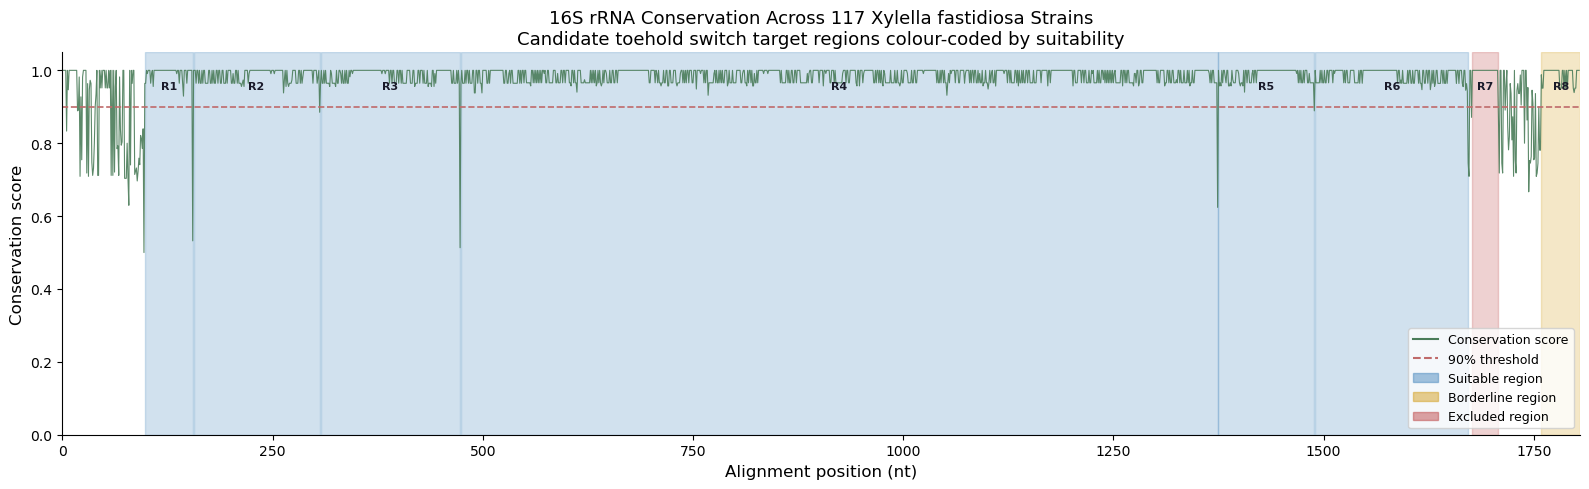

Conservation plot saved to /home/andre/xylella-toehold-biosensor/results/conservation_plot.png


In [31]:
fig, ax = plt.subplots(figsize=(16, 5))

# Plot conservation score across all alignment positions
ax.plot(
    conservation_scores,
    color="#4a7c59",
    linewidth=0.8,
    alpha=0.9,
    label="Conservation score"
)

# Shade the 90% threshold line
ax.axhline(
    y=0.90,
    color="#bf6a6a",
    linewidth=1.2,
    linestyle="--",
    label="90% threshold"
)

# Colour code regions by suitability
region_colours = {
    "SUITABLE": "#4a8abf",
    "BORDERLINE": "#d4a020",
    "EXCLUDE": "#bf4a4a"
}

for i, (start, end, length) in enumerate(conserved_regions):
    region_id = f"R{i+1}"
    row = regions_df[regions_df["region_id"] == region_id].iloc[0]
    seq_len = row["sequence_length"]
    
    if seq_len == 0:
        colour = region_colours["EXCLUDE"]
    elif seq_len < 50:
        colour = region_colours["BORDERLINE"]
    else:
        colour = region_colours["SUITABLE"]
    
    ax.axvspan(start, end, alpha=0.25, color=colour)
    ax.text(
        (start + end) / 2,
        0.95,
        region_id,
        ha="center",
        fontsize=8,
        color="#1a1a2a",
        fontweight="bold"
    )

# Custom legend
suitable_patch = mpatches.Patch(
    color="#4a8abf", alpha=0.5, label="Suitable region"
)
borderline_patch = mpatches.Patch(
    color="#d4a020", alpha=0.5, label="Borderline region"
)
exclude_patch = mpatches.Patch(
    color="#bf4a4a", alpha=0.5, label="Excluded region"
)

ax.legend(
    handles=[
        plt.Line2D([0], [0], color="#4a7c59", linewidth=1.5,
                   label="Conservation score"),
        plt.Line2D([0], [0], color="#bf6a6a", linewidth=1.5,
                   linestyle="--", label="90% threshold"),
        suitable_patch,
        borderline_patch,
        exclude_patch
    ],
    loc="lower right",
    fontsize=9
)

ax.set_xlabel("Alignment position (nt)", fontsize=12)
ax.set_ylabel("Conservation score", fontsize=12)
ax.set_title(
    "16S rRNA Conservation Across 117 Xylella fastidiosa Strains\n"
    "Candidate toehold switch target regions colour-coded by suitability",
    fontsize=13
)
ax.set_ylim(0, 1.05)
ax.set_xlim(0, len(conservation_scores))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plot_path = os.path.join(results_dir, "conservation_plot.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Conservation plot saved to {plot_path}")

## 10. Summary and next steps

Notebook 01 has completed the following.

1. Retrieved 252 Xylella fastidiosa 16S rRNA sequences from NCBI GenBank 
   using Entrez esearch and efetch with batch retrieval.

2. Applied systematic quality filtering excluding unverified, uncultured, 
   and short sequences, producing 166 sequences after filtering.

3. Applied intelligent subsampling retaining labelled subspecies sequences, 
   RefSeq reference sequences, and unspecified sequences >= 1400 nucleotides, 
   producing a curated set of 117 sequences with mean length 1498 nucleotides.

4. Extracted a Xylella fastidiosa subsp. pauca 16S rRNA sequence from the 
   complete genome NZ_CM132766.1 using Barrnap v0.9, adding critical European 
   outbreak lineage representation to the dataset.

5. Performed multiple sequence alignment of 117 sequences using MAFFT v7.526, 
   producing a 1805-position alignment.

6. Calculated per-position conservation scores identifying 95.8% of positions 
   as >= 90% conserved across all strains.

7. Identified 8 conserved regions of >= 25 nucleotides, of which 6 are 
   suitable for toehold switch design, 1 is borderline, and 1 is excluded 
   due to absence in the pauca reference sequence.

Output files produced:
- data/xylella_16S_curated.fasta: 117 curated sequences
- data/xylella_16S_aligned.fasta: MAFFT alignment
- results/candidate_regions.csv: 8 candidate regions with coordinates and sequences
- results/conservation_plot.png: per-position conservation visualisation

These outputs feed directly into notebook 02, where ViennaRNA will be used 
to predict the secondary structure of each candidate region in the native 
Xylella fastidiosa RNA context. Structurally accessible sites within the 
suitable conserved regions will be identified as the final candidate target 
sites for toehold switch design in notebook 03.